<a href="https://colab.research.google.com/github/SRET-College/Sem-6-NN-and-DL/blob/main/NN_and_DL_Lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install tensorflow
!pip install pandas numpy scikit-learn
!pip install opencv-python-headless
!pip install librosa
!pip install transformers

Looking in indexes: https://download.pytorch.org/whl/cu118


In [ ]:
import torch
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
from google.colab import drive

In [ ]:
!pip install torch-geometric
!pip install keras-tuner
!pip install dgl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 67.1 MB/s eta 0:00:00


In [ ]:
import torch-geometric
import keras-tuner
import dgl

In [ ]:
# Check whether GPU is available for PyTorch
print("GPU available:", torch.cuda.is_available())

# Print number of GPUs available
print("GPU count:", torch.cuda.device_count())

# If GPU is available, print the GPU name
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

GPU available: True
GPU count: 1
GPU name: Tesla T4


In [ ]:
# Mount Google Drive to access large datasets stored in Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load CSV (most common tabular format)
df = pd.read_csv("/content/drive/MyDrive/E0123015/Chocolate Sales.csv")

In [ ]:
df

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,"$5,303.58",354
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,"$7,339.32",121
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,$616.09,238
3280,Dotty Strutley,India,Eclairs,28/07/2024,"$2,504.62",397


In [ ]:
# Load regular JSON file
df = pd.read_json("/content/drive/MyDrive/E0123015/inventory.json")

In [ ]:
df

,id,category,name,price,stock,rating
0,101,Electronics,Wireless Mouse,25.99,150,4.5
1,102,Electronics,Mechanical Keyboard,89.50,45,4.8
2,103,Home Decor,Floating Shelves,34.00,12,4.2
3,104,Kitchen,Air Fryer,120.00,80,4.7
4,105,Office,Ergonomic Chair,199.99,5,4.9
5,106,Kitchen,Chef's Knife,55.25,0,4.6
6,107,Electronics,USB-C Hub,45.00,200,4.3
7,108,Fitness,Yoga Mat,29.99,60,4.4
8,109,Home Decor,Ceramic Vase,15.50,25,4.0
9,110,Electronics,Noise Cancelling Headphones,249.00,30,4.9


In [ ]:
# Load TSV (tab‑separated)
df = pd.read_csv("/content/drive/MyDrive/E0123015/E_Commerce.tsv", sep="\t")

In [ ]:
df

,ProductID,Category,ProductName,Price,Stock,Rating,Status
0,101,Electronics,Wireless Mouse,25.99,150,4.5,In Stock
1,102,Electronics,Mechanical Keyboard,89.50,45,4.8,In Stock
2,103,Home Decor,Floating Shelves,34.00,12,4.2,In Stock
3,104,Kitchen,Air Fryer,120.00,80,4.7,In Stock
4,105,Office,Ergonomic Chair,199.99,5,4.9,Low Stock
5,106,Kitchen,Chef's Knife,55.25,0,4.6,Out of Stock
6,107,Electronics,USB-C Hub,45.00,200,4.3,In Stock
7,108,Fitness,Yoga Mat,29.99,60,4.4,In Stock
8,109,Home Decor,Ceramic Vase,15.50,25,4.0,In Stock
9,110,Electronics,Noise Cancelling Headphones,249.00,30,4.9,In Stock


In [ ]:
df = pd.read_csv("/content/sample_data/california_housing_train.csv")

In [ ]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


In [ ]:
from sklearn.datasets import load_diabetes
x, y = load_diabetes(return_X_y=True)

In [ ]:
print(X.shape)
print(y.shape)
print(x, y)

(442, 10)
(442,)
[[ 0.03807591  0.05068012  0.06169621 ... -0.00259226  0.01990749
  -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [ 0.04170844  0.05068012 -0.01590626 ... -0.01107952 -0.04688253
   0.01549073]
 [-0.04547248 -0.04464164  0.03906215 ...  0.02655962  0.04452873
  -0.02593034]
 [-0.04547248 -0.04464164 -0.0730303  ... -0.03949338 -0.00422151
   0.00306441]] [151.  75. 141. 206. 135.  97. 138.  63. 110. 310. 101.  69. 179. 185.
 118. 171. 166. 144.  97. 168.  68.  49.  68. 245. 184. 202. 137.  85.
 131. 283. 129.  59. 341.  87.  65. 102. 265. 276. 252.  90. 100.  55.
  61.  92. 259.  53. 190. 142.  75. 142. 155. 225.  59. 104. 182. 128.
  52.  37. 170. 170.  61. 144.  52. 128.  71. 163. 150.  97. 160. 178.
  48. 270. 202. 111.  85.  42. 170. 200. 252. 113. 143.  51.  52. 210.
  65. 141.  55. 134.  42. 111.  98. 164.  48.  96.  90. 162. 150.

In [ ]:
from sklearn.datasets import load_wine, load_breast_cancer

# Wine: 3 classes (types of cultivars)
X_wine, y_wine = load_wine(return_X_y=True)

# Breast Cancer: 2 classes (Malignant or Benign)
X_cancer, y_cancer = load_breast_cancer(return_X_y=True)

In [ ]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

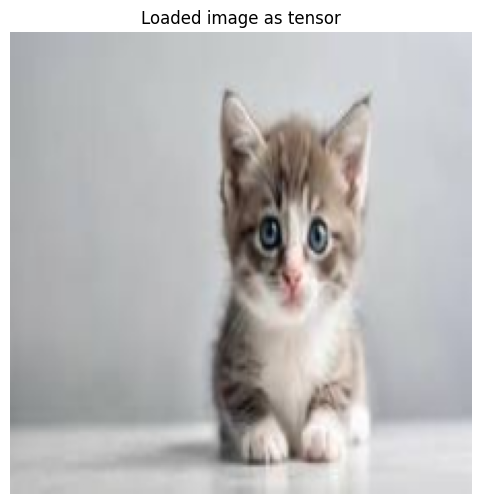

In [ ]:
# Import OpenCV library (used for image processing; not directly used here)
import cv2

# Import PIL to load images in Python
from PIL import Image

# Import PyTorch library
import torch

# Import matplotlib for displaying images
import matplotlib.pyplot as plt

# Import torchvision transforms for image preprocessing
from torchvision import transforms


# -------------------------------
# STEP 1: Load the image using PIL
# -------------------------------

# Open the image file from the given path
pil_img = Image.open("/content/drive/MyDrive/E0123015/Untitled image.jpg")


# -------------------------------------
# STEP 2: Define image transformations
# -------------------------------------

# Resize image to 224x224 (standard input size for CNNs)
# Convert image to PyTorch tensor (values scaled to [0, 1])
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


# -------------------------------------
# STEP 3: Apply transforms to the image
# -------------------------------------

# Apply preprocessing and convert PIL image to tensor
# Shape becomes: [3, 224, 224] → (Channels, Height, Width)
img_tensor = transform(pil_img)

# Add batch dimension required by deep learning models
# Final shape: [1, 3, 224, 224]
img_tensor = img_tensor.unsqueeze(0)


# -------------------------------------
# STEP 4: Visualize the image
# -------------------------------------

# Create a figure with fixed size
plt.figure(figsize=(6, 6))

# Remove batch dimension: [3, 224, 224]
# Change tensor order from (C, H, W) to (H, W, C)
# Convert tensor to NumPy array for matplotlib
img_np = img_tensor[0].permute(1, 2, 0).numpy()

# Display the image
plt.imshow(img_np)

# Hide axis values for cleaner visualization
plt.axis("off")

# Set title for the image
plt.title("Loaded image as tensor")

# Show the image
plt.show()


In [ ]:
# Import librosa library for audio processing
import librosa

# -------------------------------------
# STEP 1: Load the audio file
# -------------------------------------

# Load the audio file from the given path
# audio → 1D NumPy array containing the audio signal (amplitude values)
# sr → sample rate of the audio (samples per second)
# sr=None ensures the original sample rate is preserved
filename = librosa.ex('trumpet')

audio, sr = librosa.load(filename, sr=None)


# -------------------------------------
# STEP 2: Display basic audio information
# -------------------------------------

# Print the sample rate of the audio file
print("Sample rate:", sr)

# Print the shape of the audio array
# Length indicates number of audio samples
print("Audio shape:", audio.shape)

Sample rate: 22050
Audio shape: (117601,)


In [ ]:
!wget https://www.gutenberg.org -O sherlock.txt

--2026-02-03 06:24:35--  https://www.gutenberg.org/
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27900 (27K) [text/html]
Saving to: ‘sherlock.txt’

sherlock.txt        100%[===================>]  27.25K  --.-KB/s    in 0s      

2026-02-03 06:24:35 (361 MB/s) - ‘sherlock.txt’ saved [27900/27900]



In [ ]:
# Load entire text file
with open("sherlock.txt", "r", encoding="utf-8") as f:
    text = f.read()

# Load line‑by‑line
with open("sherlock.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()

In [ ]:
# -----------------------------------
# SINGLE NEURON: FORWARD PASS ONLY
# Input → Weights → Sum → Activation → Output
# -----------------------------------

import numpy as np

# Step 1: Input values
inputs = np.array([1, 2])     # x1 = 1, x2 = 2

# Step 2: Weights
weights = np.array([0.4, 0.6])  # w1, w2

# Step 3: Bias
bias = 0.2

# Step 4: Weighted sum
weighted_sum = np.dot(inputs, weights) + bias

# Step 5: Activation function (Sigmoid)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Step 6: Output
output = sigmoid(weighted_sum)

# Step 7: Print each stage
print("Input:", inputs)
print("Weights:", weights)
print("Weighted Sum (z):", weighted_sum)
print("Final Output:", output)


Input: [1 2]
Weights: [0.4 0.6]
Weighted Sum (z): 1.8
Final Output: 0.8581489350995123


In [ ]:
# ----------------------------------------
# BASIC NEURAL NETWORK IMPLEMENTATION
# ----------------------------------------

# Step 1: Import required library
import numpy as np

# Step 2: Define input data (AND logic)
# Each row is one input sample
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

# Step 3: Define expected output
# AND logic output
y = np.array([[0],
              [0],
              [0],
              [1]])

# Step 4: Initialize weights and bias randomly
# 2 input neurons -> 1 output neuron
weights = np.random.rand(2, 1)
bias = np.random.rand(1)

# Step 5: Define activation function (Sigmoid)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Step 6: Define derivative of sigmoid
def sigmoid_derivative(x):
    return x * (1 - x)

# Step 7: Training parameters
learning_rate = 0.1
epochs = 10000

# Step 8: Training the neural network
for epoch in range(epochs):

    # Forward propagation
    z = np.dot(X, weights) + bias        # Weighted sum
    output = sigmoid(z)                  # Activation output

    # Calculate error
    error = y - output

    # Backpropagation
    d_output = error * sigmoid_derivative(output)

    # Update weights and bias
    weights += learning_rate * np.dot(X.T, d_output)
    bias += learning_rate * np.sum(d_output)

# Step 9: Display final results
print("Final Weights:\n", weights)
print("Final Bias:\n", bias)

# Step 10: Test the network
print("\nPredicted Output after Training:")
print(output)

Final Weights:
 [[5.48187132]
 [5.48187132]]
Final Bias:
 [-8.31548824]

Predicted Output after Training:
[[2.44680234e-04]
 [5.55374185e-02]
 [5.55374183e-02]
 [9.33899685e-01]]


In [ ]:
# Download a 10-second sample video of a flower
!wget https://interactive-examples.mdn.mozilla.net/media/cc0-videos/flower.mp4 -O sample_video.mp4

--2026-02-03 06:28:06--  https://interactive-examples.mdn.mozilla.net/media/cc0-videos/flower.mp4
Resolving interactive-examples.mdn.mozilla.net (interactive-examples.mdn.mozilla.net)... 34.111.242.42, 2600:1901:0:578b::
Connecting to interactive-examples.mdn.mozilla.net (interactive-examples.mdn.mozilla.net)|34.111.242.42|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1128375 (1.1M) [video/mp4]
Saving to: ‘sample_video.mp4’

sample_video.mp4    100%[===================>]   1.08M  --.-KB/s    in 0.006s  

2026-02-03 06:28:06 (186 MB/s) - ‘sample_video.mp4’ saved [1128375/1128375]



In [ ]:
from IPython.display import HTML
from base64 import b64encode

# Play a local mp4 file in the notebook
mp4 = open('sample_video.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f'<video width=400 controls><source src="{data_url}" type="video/mp4"></video>')


In [ ]:
import cv2

# Initialize video capture
cap = cv2.VideoCapture('sample_video.mp4')

# Read the first frame
ret, frame = cap.read()
if ret:
    print(f"Frame dimensions: {frame.shape}") # (Height, Width, Channels)

cap.release()


Frame dimensions: (540, 960, 3)
